<a href="https://colab.research.google.com/github/revanthnaidu24/Finanace_Complaint/blob/main/FINANCE_COMPLAINT_PROJECT%5BEDA_1%5D_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem statement

#### There is one federal agency which is in between the public and the companies[Banking sector].
#### We will use our application to verify wheather the organization gave a satisfacotory reply or not.
#### and companies can use our application for dividing the complaints which are raised from the customers to which department that each
#### Complaint belongs to. If the customer or person is not satisfied with the reply gave by the organization.

# Solution Proposed

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## !pip install gdown

In [3]:
# Install gdown if not already
# !pip install gdown

# Import gdown
import gdown

# ✅ Your file ID from the Drive link
file_id = "1xYo9CjVVXkP1IqvrdpWLLStOZSVIH2gk"

# ✅ Download it as complaints.csv
gdown.download(f"https://drive.google.com/uc?id={file_id}", "complaints.csv", quiet=False)

# ✅ Load into pandas
import pandas as pd
df = pd.read_csv("complaints.csv")
df.head(5)


Downloading...
From (original): https://drive.google.com/uc?id=1xYo9CjVVXkP1IqvrdpWLLStOZSVIH2gk
From (redirected): https://drive.google.com/uc?id=1xYo9CjVVXkP1IqvrdpWLLStOZSVIH2gk&confirm=t&uuid=a4818042-3be3-4bbf-ae8e-e9574c38c2a3
To: /content/complaints.csv
100%|██████████| 4.50G/4.50G [01:18<00:00, 57.1MB/s]


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2021-08-02,"Credit reporting, credit repair services, or o...",Other personal consumer report,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"Early Warning Services, LLC",GA,30326,NaN,Consent not provided,Web,2021-08-02,Closed with explanation,Yes,NaN,4595929
1,2021-08-02,Debt collection,Credit card debt,Took or threatened to take negative or legal a...,Threatened to sue you for very old debt,Original Debt is from XXXX in the amount of {$...,NaN,"Revco Management, LLC",VA,23513,NaN,Consent provided,Web,2021-08-03,Closed with non-monetary relief,Yes,NaN,4596680
2,2014-05-16,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,"EQUIFAX, INC.",FL,33283,NaN,NaN,Postal mail,2014-06-10,Closed with non-monetary relief,Yes,Yes,856572
3,2013-08-20,Bank account or service,Checking account,"Account opening, closing, or management",NaN,NaN,NaN,BB&T CORPORATION,CA,94107,NaN,NaN,Referral,2013-08-22,Closed with explanation,Yes,Yes,499423
4,2017-03-04,Debt collection,Medical,Disclosure verification of debt,Not given enough info to verify debt,NaN,NaN,FRESNO CREDIT BUREAU,CA,92117,NaN,Consent not provided,Web,2017-03-08,Closed with explanation,Yes,No,2371613


#### We will extract the data  base from the [customer complaint data base].
#### Preprocessing the data and feature extraction.
#### Training machine learning modles for the classification.
#### We need to know which algorithm we need to use based on the given data.

In [4]:
df.shape

(6870033, 18)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6870033 entries, 0 to 6870032
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Consumer consent provided?    object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), object(17)
memory usage: 943.

In [6]:
df['Issue'].value_counts()

,count
Issue,
Incorrect information on your report,2246987
Improper use of your report,1250191
Problem with a credit reporting company's investigation into an existing problem,589336
Problem with a company's investigation into an existing problem,500756
Attempts to collect debt not owed,253186
...,...
Lender damaged or destroyed vehicle,8
Property was damaged or destroyed property,7
Lender sold the property,7


#### From data we can see that the a lot of the customers gave the wrong information in the complaint.

In [7]:
df['Company'].value_counts()

,count
Company,
"EQUIFAX, INC.",1551572
"TRANSUNION INTERMEDIATE HOLDINGS, INC.",1499373
Experian Information Solutions Inc.,1377591
"BANK OF AMERICA, NATIONAL ASSOCIATION",148341
WELLS FARGO & COMPANY,136972
...,...
Federal Trade Commission,1
MyCRD,1
Kiva Microfunds,1


#### For the EQIFAX, inc. is having more number of issues from the customers.

In [8]:
df['Date received'].value_counts()

,count
Date received,
2024-10-22,11818
2024-09-17,11765
2024-11-07,11709
2024-10-08,11642
2024-10-15,11605
...,...
2011-12-24,11
2011-12-25,10
2017-04-22,9


#### From this we can justify that the 2024-10-22 got more number of complaints from the customers.

In [9]:
df.replace('',np.nan,inplace=True)

In [10]:
df['Tags'].value_counts()

,count
Tags,
Servicemember,328120
Older American,172952
"Older American, Servicemember",43859


In [11]:
summary = []

for col in df.columns:
    col_data = df[col]
    col_summary = {
        'Column Name': col,
        'Count': col_data.count(),  # Non-null count
        'Unique Values': col_data.nunique(),  # Number of unique values
    }

    if col_data.dtype == 'object' or col_data.dtype == 'category':
        col_summary['Top Frequency'] = col_data.value_counts().idxmax()  # Most frequent value
        col_summary['Frequency Count'] = col_data.value_counts().max()   # Count of the most frequent value
    else:
        col_summary['Top Frequency'] = None
        col_summary['Frequency Count'] = None

    summary.append(col_summary)

summary_df = pd.DataFrame(summary)

print(summary_df)

                     Column Name    Count  Unique Values  \
0                  Date received  6870033           4749   
1                        Product  6870033             21   
2                    Sub-product  6634738             86   
3                          Issue  6870027            178   
4                      Sub-issue  6113619            272   
5   Consumer complaint narrative  2299122        1750712   
6        Company public response  3394844             11   
7                        Company  6870033           7450   
8                          State  6820969             63   
9                       ZIP code  6839805          34186   
10                          Tags   544931              3   
11    Consumer consent provided?  5638900              4   
12                 Submitted via  6870033              7   
13          Date sent to company  6870033           4698   
14  Company response to consumer  6870013              8   
15              Timely response?  687003

#### Checking the the unique values for our target variable

In [12]:
df['Consumer disputed?'].value_counts(normalize=True)*100

,proportion
Consumer disputed?,
No,80.687743
Yes,19.312257


#### The above data is imbalanced.
#### Balaced data is 75,25 or 70 and 30.

### Dividig the data into categorical and numerical columns.

In [13]:
categorical_features=[]
numeric_features=[]

for i in df.columns:
    if df[i].dtype == 'object':
        categorical_features.append(i)
    else:
        numeric_features.append(i)
print("Categorical Variables: ",categorical_features)




Categorical Variables:  ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?']


In [14]:
print("Numerical Variables: ",numeric_features)

Numerical Variables:  ['Complaint ID']


In [15]:
a=df.isnull().sum().sort_values(ascending=False)
a

,0
Tags,6325102
Consumer disputed?,6101723
Consumer complaint narrative,4570911
Company public response,3475189
Consumer consent provided?,1231133
Sub-issue,756414
Sub-product,235295
State,49064
ZIP code,30228
Company response to consumer,20


In [16]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')

#### My main target variable is Consumer disputed we cant able to remove that.
#### Tags is not that much important for me i can remove that using drop function use inplace=true foor complete chnage in the original data too.

In [17]:
 # df.drop(columns=['Complaint ID','Tags','Sub-issue','Sub-product'], axis=1, inplace=True)

### Top null values.

# Because complaint is every data is unique. So we can't able to form a normal distribution on that if we want to perform a model
# we need to have a good data which contains normal distribution.
# Tags has more number of null values which is 95% of the total data points.
# Consumer disputed we cant able to remove that because its our target variable.
# Sub is not that much important for us.

In [18]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')

In [19]:
df.isnull().sum()

,0
Date received,0
Product,0
Sub-product,235295
Issue,6
Sub-issue,756414
Consumer complaint narrative,4570911
Company public response,3475189
Company,0
State,49064
ZIP code,30228


#### if you using the NLP then you need to keep the complaint narrative and the public response?


In [20]:
for col in df.columns:
    print(col, df[col].nunique())

Date received 4749
Product 21
Sub-product 86
Issue 178
Sub-issue 272
Consumer complaint narrative 1750712
Company public response 11
Company 7450
State 63
ZIP code 34186
Tags 3
Consumer consent provided? 4
Submitted via 7
Date sent to company 4698
Company response to consumer 8
Timely response? 2
Consumer disputed? 2
Complaint ID 6870033


#### From above data .Products means complains are 21 are similar.
#### total unique compaies are 7450

# Visualization

In [21]:
# Pie char for the Target variable

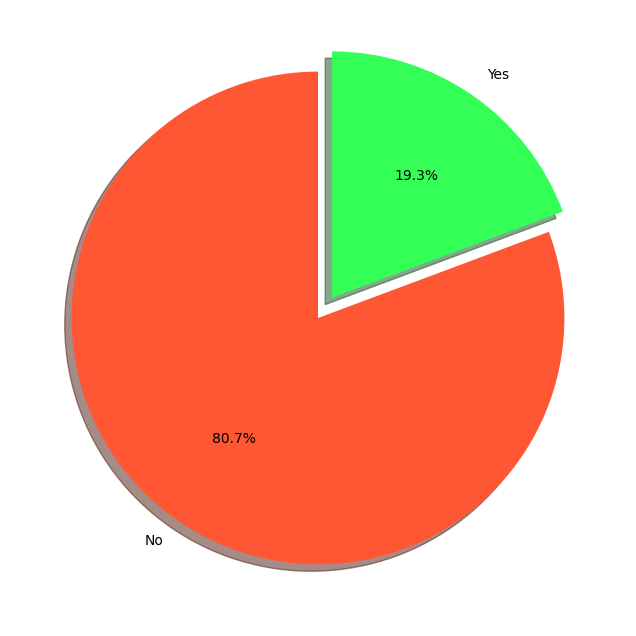

In [22]:
percentage = df['Consumer disputed?'].value_counts(normalize=True)*100
label=['No','Yes']

# Pie chart visualization.
fig,ax = plt.subplots(figsize=(15,8))
explode=(0,0.1)
colors=['#FF5733', '#33FF57']
ax.pie(percentage, labels=label, startangle=90, autopct='%1.1f%%', explode=explode, shadow=True, colors=colors)
plt.show()



#### The above graph shows 80% of the customers are not raising any dispute and 19.3 are raising a dispute clearly we can say that this data is imbalaced data.

In [23]:
df.head(3)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2021-08-02,"Credit reporting, credit repair services, or o...",Other personal consumer report,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"Early Warning Services, LLC",GA,30326,NaN,Consent not provided,Web,2021-08-02,Closed with explanation,Yes,NaN,4595929
1,2021-08-02,Debt collection,Credit card debt,Took or threatened to take negative or legal a...,Threatened to sue you for very old debt,Original Debt is from XXXX in the amount of {$...,NaN,"Revco Management, LLC",VA,23513,NaN,Consent provided,Web,2021-08-03,Closed with non-monetary relief,Yes,NaN,4596680
2,2014-05-16,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,"EQUIFAX, INC.",FL,33283,NaN,NaN,Postal mail,2014-06-10,Closed with non-monetary relief,Yes,Yes,856572


In [24]:
c = df['Product'].value_counts(normalize=True)*100
c.to_frame()[0:10]

,proportion
Product,
Credit reporting or other personal consumer reports,35.649654
"Credit reporting, credit repair services, or other personal consumer reports",31.497258
Debt collection,9.611570
Mortgage,5.959229
Checking or savings account,3.530711
Credit card or prepaid card,3.003959
Credit card,2.585126
Credit reporting,2.044080
Student loan,1.390939


#### From above you can see that the more complaints are based on the credit reporting and debt collection
#### But the least are bank account and the student loan.

#### Visulaizing the data in the form a pie chart.

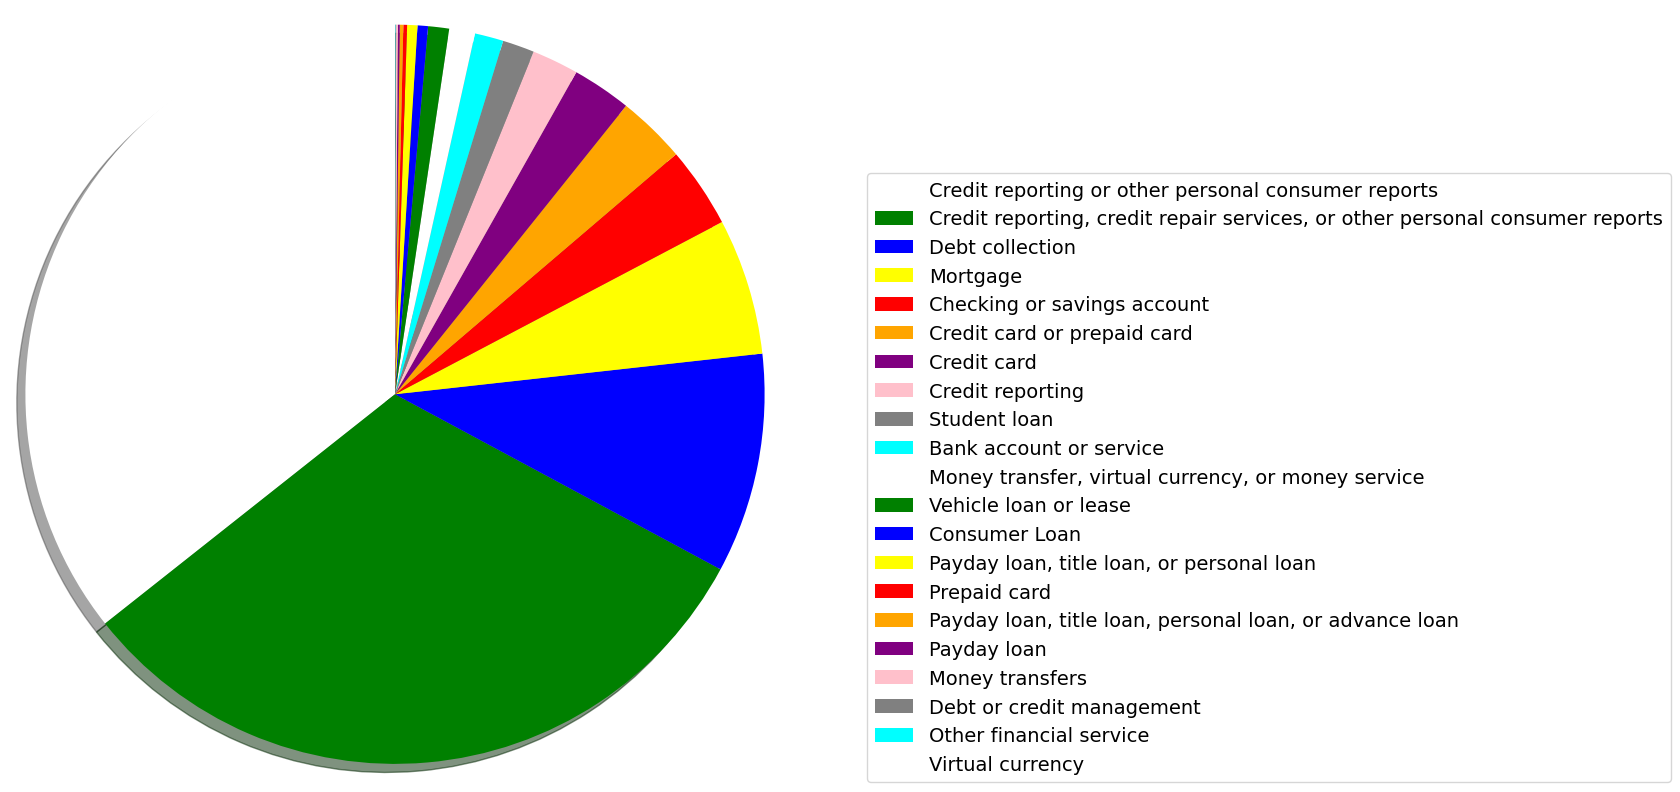

In [25]:
product_percentage = df['Product'].value_counts(normalize=True)*100
labels = c.index
colors = ['white', 'green', 'blue', 'yellow', 'red', 'orange', 'purple', 'pink', 'gray', 'cyan']
fig,ax = plt.subplots(figsize=(18,10))
patches,texts = ax.pie(product_percentage, startangle=90, shadow=True, colors=colors, radius=1.2)
plt.legend(patches,labels, loc='best', bbox_to_anchor=(1.1, 0.5, 0.5, 0.3), fontsize=14)

plt.show()


In [26]:
df.head(3)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2021-08-02,"Credit reporting, credit repair services, or o...",Other personal consumer report,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"Early Warning Services, LLC",GA,30326,NaN,Consent not provided,Web,2021-08-02,Closed with explanation,Yes,NaN,4595929
1,2021-08-02,Debt collection,Credit card debt,Took or threatened to take negative or legal a...,Threatened to sue you for very old debt,Original Debt is from XXXX in the amount of {$...,NaN,"Revco Management, LLC",VA,23513,NaN,Consent provided,Web,2021-08-03,Closed with non-monetary relief,Yes,NaN,4596680
2,2014-05-16,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,"EQUIFAX, INC.",FL,33283,NaN,NaN,Postal mail,2014-06-10,Closed with non-monetary relief,Yes,Yes,856572


In [27]:
states=df['State'].value_counts(normalize=True)*100



<Axes: xlabel='State'>

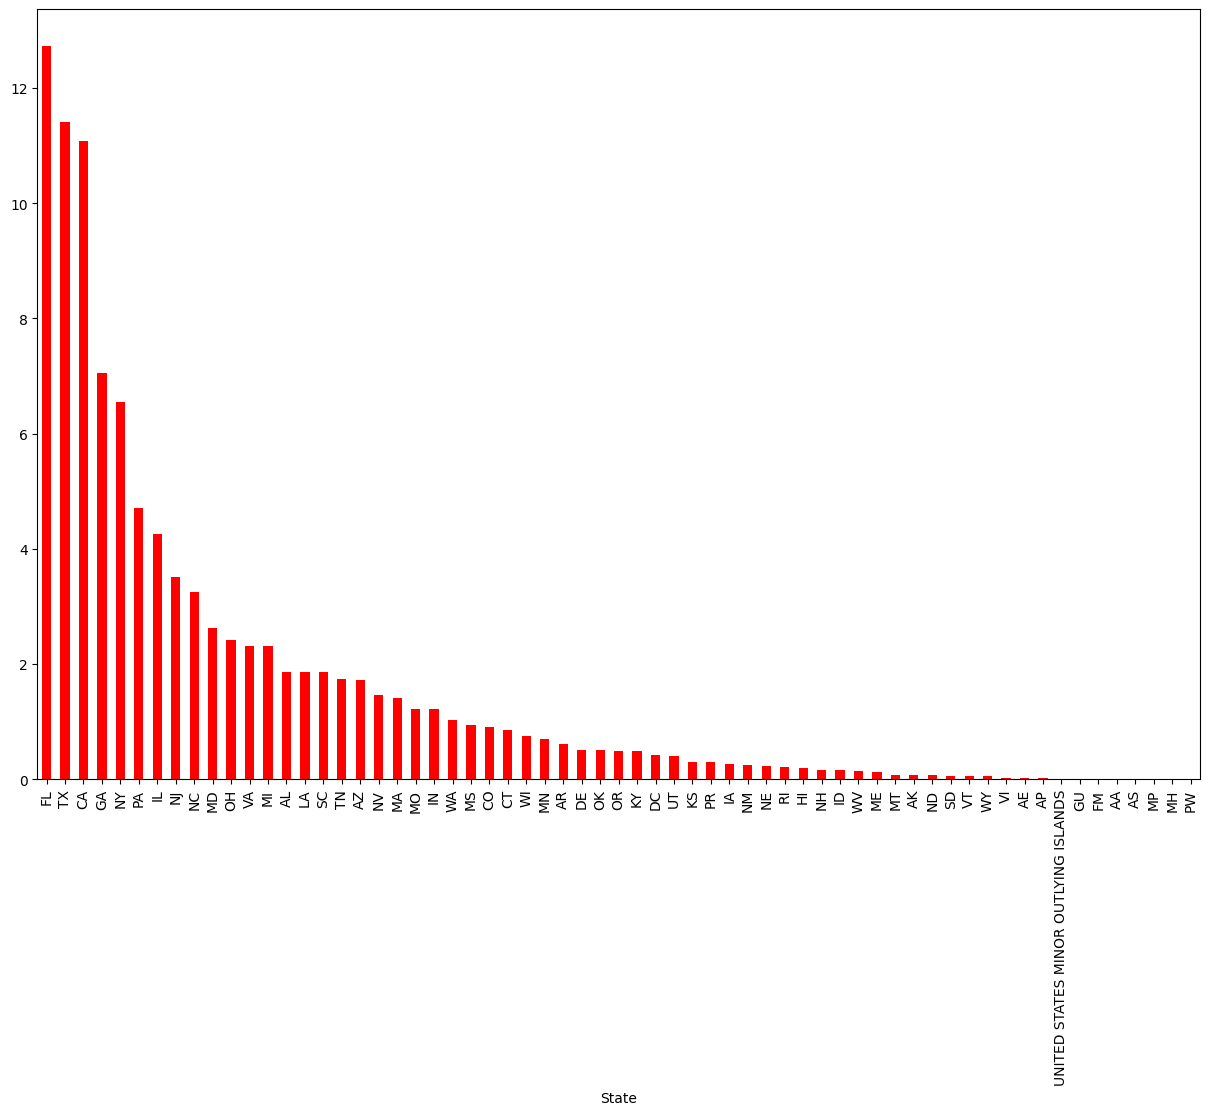

In [28]:
plt.subplots(figsize=(15,10))
states.plot(kind='bar',color='Red')

In [29]:
df.rename(columns={'Consumer disputed?': 'Consumer_disputed'}, inplace=True)
df.rename(columns={'Company response to consumer': 'Company_response_to_consumer'}, inplace=True)


In [30]:
# From above we can see that the floridda is in the first position and the texas,
# california from these states more no of complaints are noticed.
# The companies should need to be focused o these states first.

In [31]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company_response_to_consumer',
       'Timely response?', 'Consumer_disputed', 'Complaint ID'],
      dtype='object')

In [32]:
df.groupby('Company_response_to_consumer')['Consumer_disputed'].value_counts(normalize=True).to_frame()*100

proportion
Company_response_to_consumer    Consumer_disputed            
Closed                          No                  79.416274
                                Yes                 20.583726
Closed with explanation         No                  78.771647
                                Yes                 21.228353
Closed with monetary relief     No                  89.415405
                                Yes                 10.584595
Closed with non-monetary relief No                  88.370777
                                Yes                 11.629223
Closed with relief              No                  86.651584
                                Yes                 13.348416
Closed without relief           No                  73.074771
                                Yes                 26.925229
Untimely response               No                  99.926794
                                Yes                  0.073206

#### groupby function is used to group the unique statements given by the company to the customers and wheather
#### they have disputed the response came from the company or not.
#### Closed with the monetary relief has less disputed percentage from the customers. Means that the most of the customers are
#### satisfied with the response gave by the company in this particular filed.
#### Mainly the company should focus on the closed without the relief has more dispute percnatge.

In [33]:
disputed_df = df[df.Consumer_disputed =='Yes']
disputed_df.Company_response_to_consumer.value_counts(normalize=True)*100

,proportion
Company_response_to_consumer,
Closed with explanation,82.690830
Closed with non-monetary relief,7.479545
Closed with monetary relief,3.665638
Closed without relief,3.242394
Closed,2.443085
Closed with relief,0.477160
Untimely response,0.001348


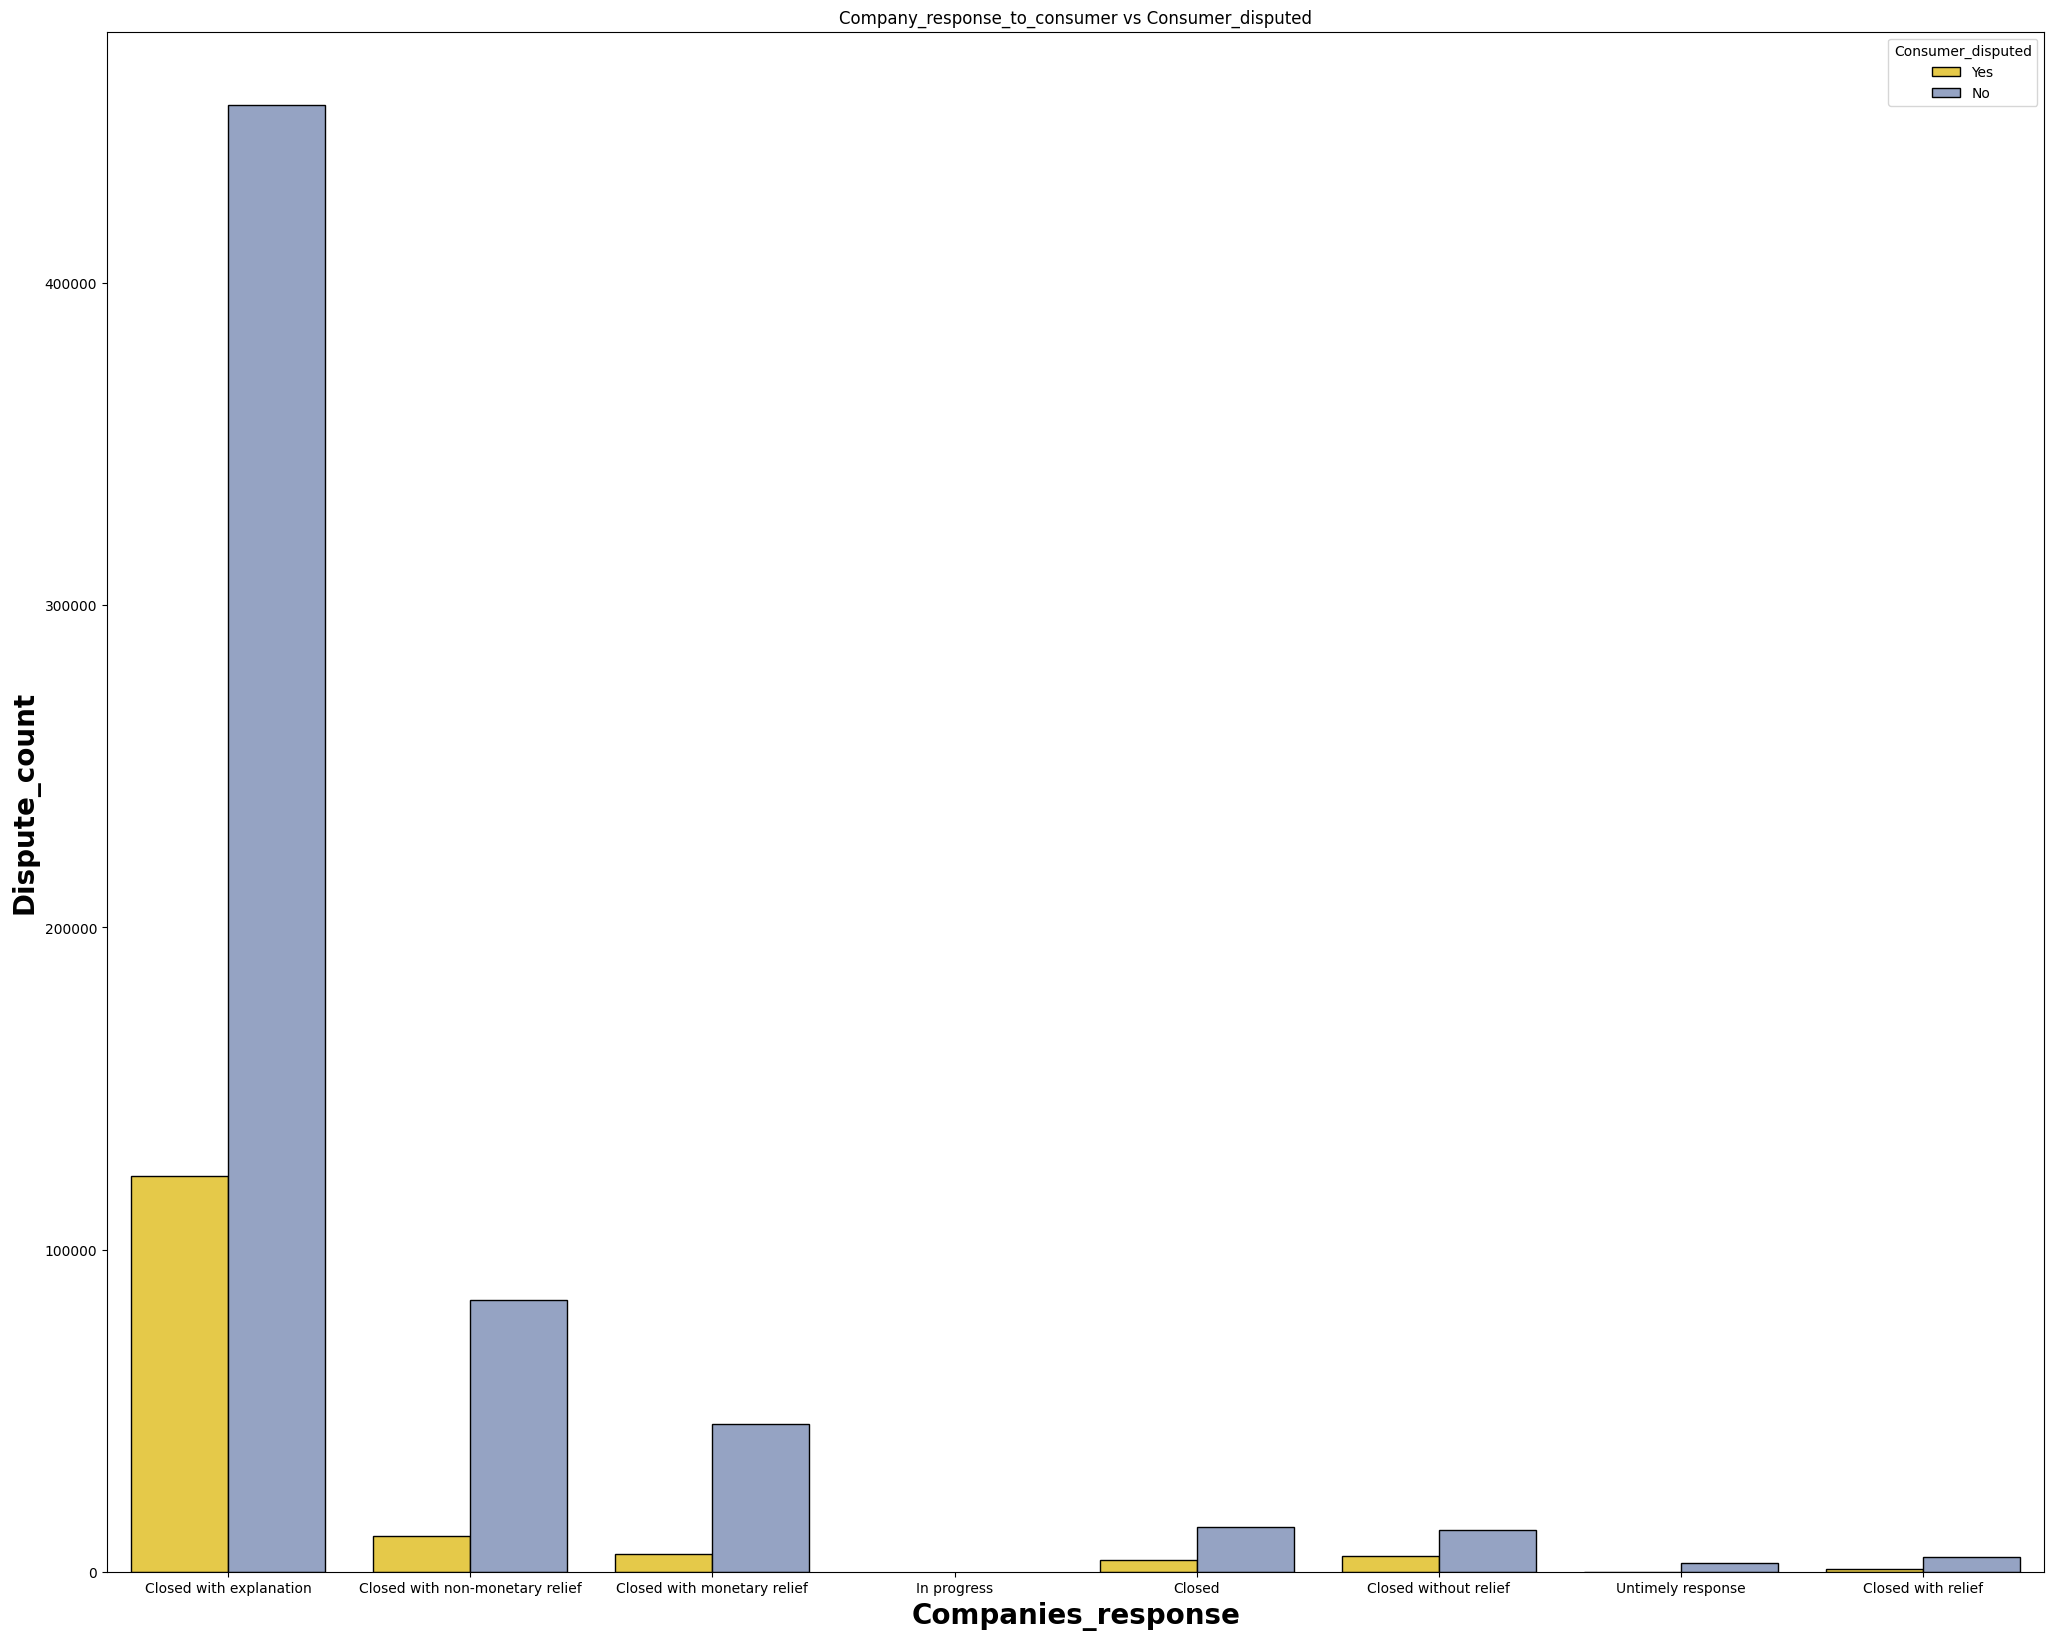

In [34]:
plt.subplots(figsize=(25,20))
sns.countplot(x='Company_response_to_consumer',hue='Consumer_disputed',data=df, ec='black',palette='Set2_r')
plt.title('Company_response_to_consumer vs Consumer_disputed')
plt.ylabel('Dispute_count',weight='bold',fontsize=20)
plt.xlabel('Companies_response',weight='bold',fontsize=20)
plt.show()

# Finacial year vs Consumer dispute.

In [35]:
viz_df = disputed_df.copy()

In [36]:
viz_df['recieved_date'] = pd.to_datetime(viz_df['Date received']).dt.date
viz_df['recieved_month'] = pd.to_datetime(viz_df['recieved_date']).dt.month
viz_df['recieved_year'] = pd.to_datetime(viz_df['recieved_date']).dt.year

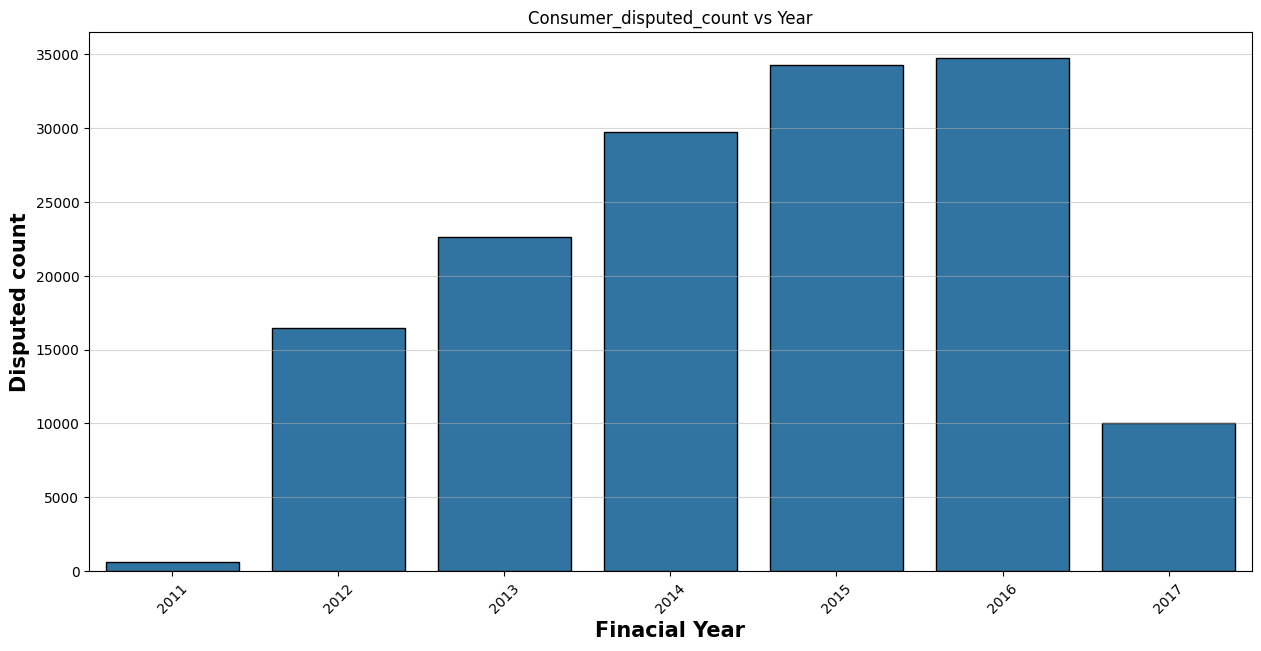

In [37]:
plt.subplots(figsize=(15,7))
sns.countplot(x='recieved_year', data=viz_df, ec='black')
plt.xticks(rotation=45)
plt.title('Consumer_disputed_count vs Year')
plt.xlabel('Finacial Year',weight='bold',fontsize=15)
plt.ylabel('Disputed count',weight='bold', fontsize=15)
plt.grid(alpha=0.5, axis="y")
plt.show()

In [38]:
# After 2016 year the company has been brilliant in their work and they have less number of disputed count.
# But from 2013 to 2016 they have high number of the disputed count and after that the count has decreased.

In [39]:
map_months = { 1:'JAN', 2: 'FEB', 3:'MAR', 4:'APR', 5:'MAY', 6:'JUN', 7:'JUL', 8:'AUG', 9:'SEP', 10:'OCT', 11:'NOV', 12:'DEC'}
viz_df = viz_df.replace({"recieved_month":map_months})

<ipython-input-40-9a8519890579>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='recieved_month', data=viz_df, ec='black', palette='rainbow',order=month_orders)


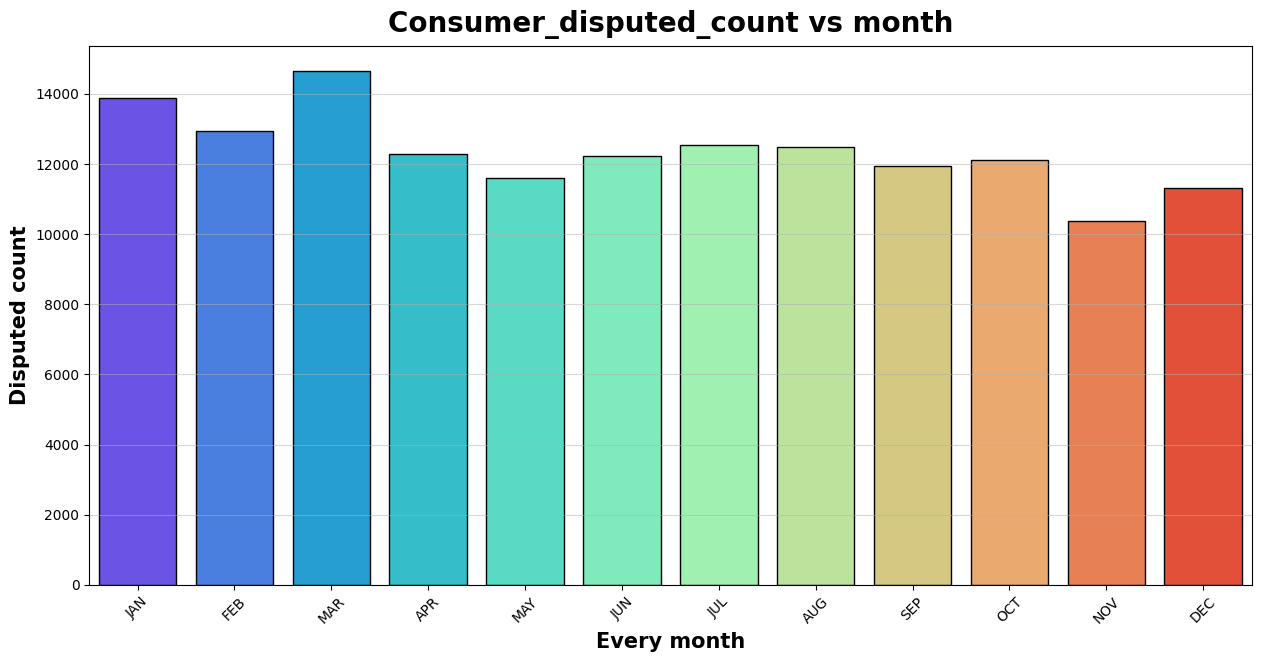

In [40]:
month_orders = ['JAN','FEB','MAR','APR','MAY','JUN','JUL','AUG','SEP','OCT','NOV','DEC']
plt.subplots(figsize=(15,7))
sns.countplot(x='recieved_month', data=viz_df, ec='black', palette='rainbow',order=month_orders)
plt.xticks(rotation=45)
plt.title('Consumer_disputed_count vs month',weight='bold',fontsize=20,pad=10)
plt.xlabel('Every month',weight='bold',fontsize=15)
plt.ylabel('Disputed count',weight='bold', fontsize=15)
plt.grid(alpha=0.5, axis="y")
plt.show()

##### HIghest disputed count is from march month.
##### Nov is the lowest compared to other months.
##### From Q1 we are having more number of complaints.

In [41]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company_response_to_consumer,Timely response?,Consumer_disputed,Complaint ID
0,2021-08-02,"Credit reporting, credit repair services, or o...",Other personal consumer report,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"Early Warning Services, LLC",GA,30326,NaN,Consent not provided,Web,2021-08-02,Closed with explanation,Yes,NaN,4595929
1,2021-08-02,Debt collection,Credit card debt,Took or threatened to take negative or legal a...,Threatened to sue you for very old debt,Original Debt is from XXXX in the amount of {$...,NaN,"Revco Management, LLC",VA,23513,NaN,Consent provided,Web,2021-08-03,Closed with non-monetary relief,Yes,NaN,4596680
2,2014-05-16,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,"EQUIFAX, INC.",FL,33283,NaN,NaN,Postal mail,2014-06-10,Closed with non-monetary relief,Yes,Yes,856572
3,2013-08-20,Bank account or service,Checking account,"Account opening, closing, or management",NaN,NaN,NaN,BB&T CORPORATION,CA,94107,NaN,NaN,Referral,2013-08-22,Closed with explanation,Yes,Yes,499423
4,2017-03-04,Debt collection,Medical,Disclosure verification of debt,Not given enough info to verify debt,NaN,NaN,FRESNO CREDIT BUREAU,CA,92117,NaN,Consent not provided,Web,2017-03-08,Closed with explanation,Yes,No,2371613


In [42]:
df.rename(columns={"Submitted via" : "Submitted_via"},inplace=True)

In [43]:
df.head(3)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted_via,Date sent to company,Company_response_to_consumer,Timely response?,Consumer_disputed,Complaint ID
0,2021-08-02,"Credit reporting, credit repair services, or o...",Other personal consumer report,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"Early Warning Services, LLC",GA,30326,NaN,Consent not provided,Web,2021-08-02,Closed with explanation,Yes,NaN,4595929
1,2021-08-02,Debt collection,Credit card debt,Took or threatened to take negative or legal a...,Threatened to sue you for very old debt,Original Debt is from XXXX in the amount of {$...,NaN,"Revco Management, LLC",VA,23513,NaN,Consent provided,Web,2021-08-03,Closed with non-monetary relief,Yes,NaN,4596680
2,2014-05-16,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,"EQUIFAX, INC.",FL,33283,NaN,NaN,Postal mail,2014-06-10,Closed with non-monetary relief,Yes,Yes,856572


In [44]:
df.Submitted_via.value_counts(normalize=True).to_frame()*100

,proportion
Submitted_via,
Web,91.671816
Referral,3.708818
Phone,2.781952
Postal mail,1.439717
Fax,0.373477
Web Referral,0.018049
Email,0.006172


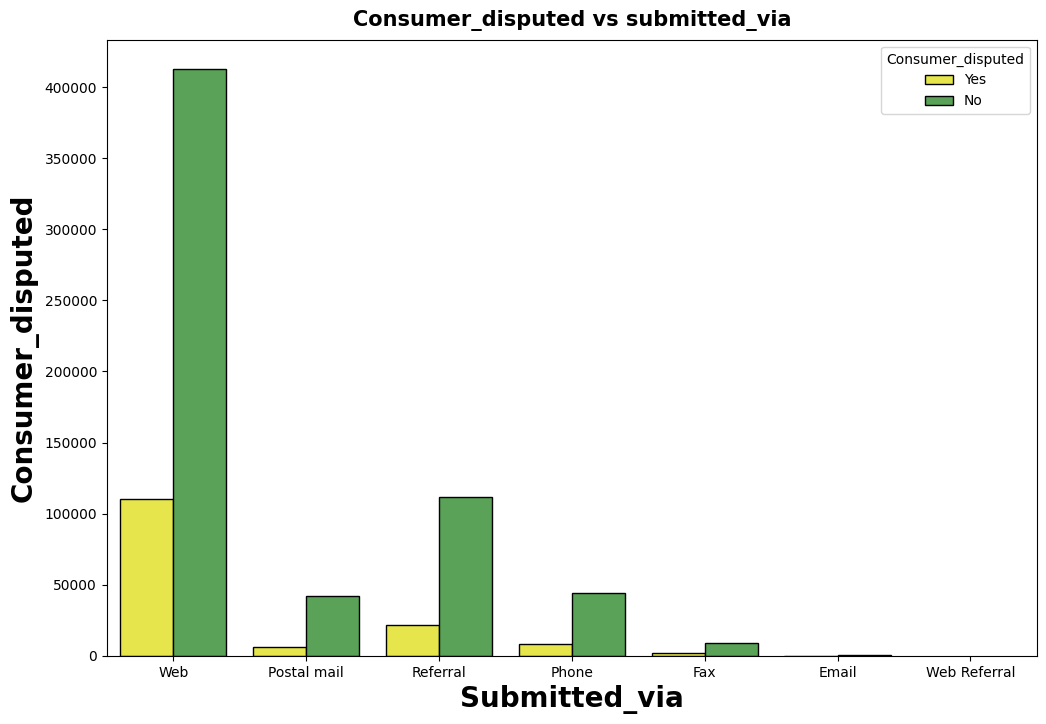

In [45]:
plt.subplots(figsize=(12,8))
sns.countplot(x='Submitted_via', hue='Consumer_disputed',data=df, ec='black', palette='Set1_r')
plt.title('Consumer_disputed vs submitted_via',weight='bold',pad=10,fontsize=15)
plt.xlabel('Submitted_via',fontsize=20,weight='bold')
plt.ylabel('Consumer_disputed',fontsize=20,weight='bold')
plt.show()

In [46]:
# Most no of disputes is from the complaints submitted by the customers via web.
# The customers or consumer are more interested in submitting the complaint via web.


In [47]:
df.head(3)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted_via,Date sent to company,Company_response_to_consumer,Timely response?,Consumer_disputed,Complaint ID
0,2021-08-02,"Credit reporting, credit repair services, or o...",Other personal consumer report,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"Early Warning Services, LLC",GA,30326,NaN,Consent not provided,Web,2021-08-02,Closed with explanation,Yes,NaN,4595929
1,2021-08-02,Debt collection,Credit card debt,Took or threatened to take negative or legal a...,Threatened to sue you for very old debt,Original Debt is from XXXX in the amount of {$...,NaN,"Revco Management, LLC",VA,23513,NaN,Consent provided,Web,2021-08-03,Closed with non-monetary relief,Yes,NaN,4596680
2,2014-05-16,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,"EQUIFAX, INC.",FL,33283,NaN,NaN,Postal mail,2014-06-10,Closed with non-monetary relief,Yes,Yes,856572


In [48]:
df.rename(columns={"Timely response?":"Timely_response"},inplace=True)
df.rename(columns={"Consumer consent provided?":"Consumer_consent_provided"},inplace=True)
df.rename(columns={"Consumer complaint narrative":"Consumer_complaint_narrative"},inplace=True)

In [49]:
df.head(3)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer_complaint_narrative,Company public response,Company,State,ZIP code,Tags,Consumer_consent_provided,Submitted_via,Date sent to company,Company_response_to_consumer,Timely_response,Consumer_disputed,Complaint ID
0,2021-08-02,"Credit reporting, credit repair services, or o...",Other personal consumer report,Incorrect information on your report,Information belongs to someone else,NaN,NaN,"Early Warning Services, LLC",GA,30326,NaN,Consent not provided,Web,2021-08-02,Closed with explanation,Yes,NaN,4595929
1,2021-08-02,Debt collection,Credit card debt,Took or threatened to take negative or legal a...,Threatened to sue you for very old debt,Original Debt is from XXXX in the amount of {$...,NaN,"Revco Management, LLC",VA,23513,NaN,Consent provided,Web,2021-08-03,Closed with non-monetary relief,Yes,NaN,4596680
2,2014-05-16,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,"EQUIFAX, INC.",FL,33283,NaN,NaN,Postal mail,2014-06-10,Closed with non-monetary relief,Yes,Yes,856572


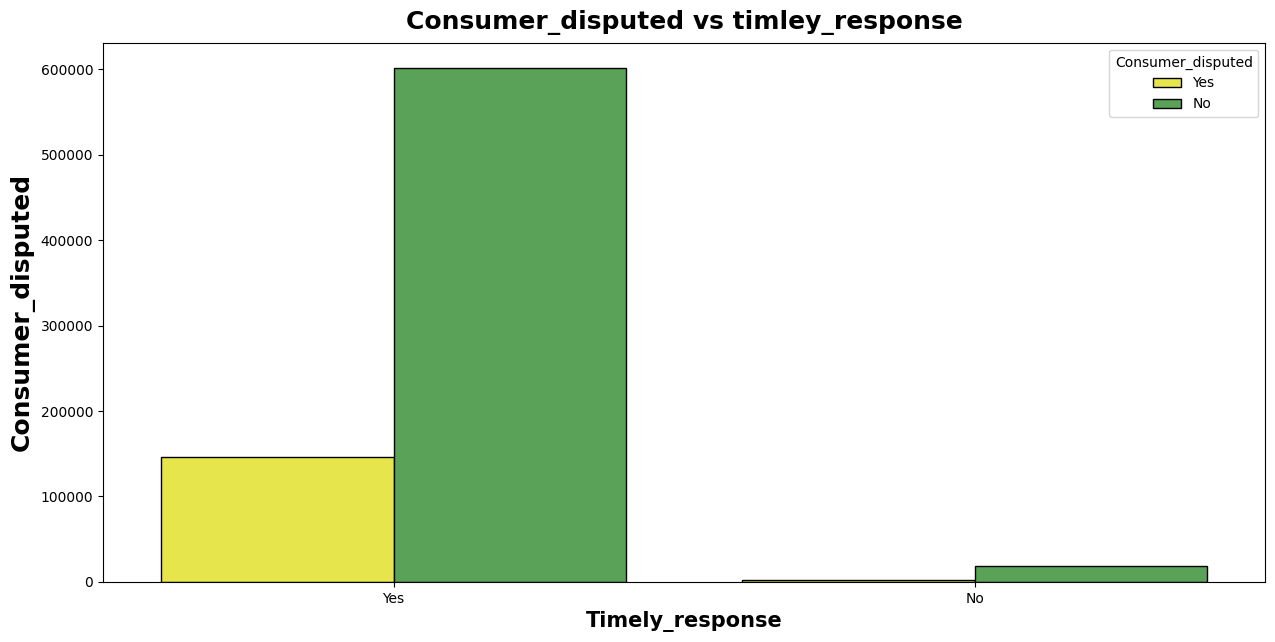

In [50]:
plt.subplots(figsize=(15,7))
sns.countplot(x='Timely_response',hue='Consumer_disputed',data=df, ec='black',palette='Set1_r')
plt.title('Consumer_disputed vs timley_response',fontsize=18,weight='bold',pad=10)
plt.xlabel('Timely_response',fontsize=15,weight='bold')
plt.ylabel('Consumer_disputed',fontsize=18,weight='bold')
plt.show()

##### In the above bar graph the timely_reposne="Yes" has more number of non-disputed compared to the dispurtes.
##### and the timley response is no then the disputes iv very very less for both the yes and no.
##### From this we ca conclude that the timely_resposne doesnt impact or contribute for my target variable.

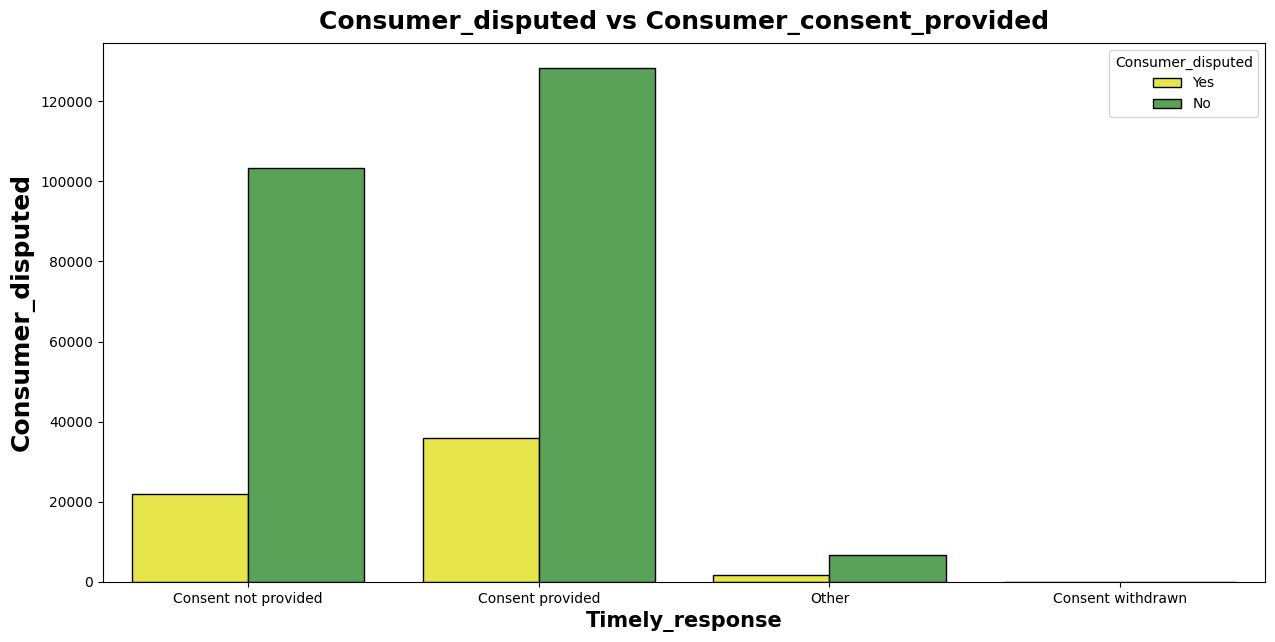

In [51]:
plt.subplots(figsize=(15,7))
sns.countplot(x='Consumer_consent_provided',hue='Consumer_disputed',data=df, ec='black',palette='Set1_r')
plt.title('Consumer_disputed vs Consumer_consent_provided',fontsize=18,weight='bold',pad=10)
plt.xlabel('Timely_response',fontsize=15,weight='bold')
plt.ylabel('Consumer_disputed',fontsize=18,weight='bold')
plt.show()

In [52]:
##### Consent provided but not disputed has more impact on the target variable.

In [53]:
df['Consumer_complaint_narrative'].value_counts().nunique()

421

In [54]:
df.drop('Consumer_complaint_narrative',axis=1, inplace=True)

In [55]:
df.drop('ZIP code',axis=1, inplace=True) ## Zip code can be removed it doesnt have any normal distribution each value is unique.
### its not useful for the model

In [56]:
df.head(3)

,Date received,Product,Sub-product,Issue,Sub-issue,Company public response,Company,State,Tags,Consumer_consent_provided,Submitted_via,Date sent to company,Company_response_to_consumer,Timely_response,Consumer_disputed,Complaint ID
0,2021-08-02,"Credit reporting, credit repair services, or o...",Other personal consumer report,Incorrect information on your report,Information belongs to someone else,NaN,"Early Warning Services, LLC",GA,NaN,Consent not provided,Web,2021-08-02,Closed with explanation,Yes,NaN,4595929
1,2021-08-02,Debt collection,Credit card debt,Took or threatened to take negative or legal a...,Threatened to sue you for very old debt,NaN,"Revco Management, LLC",VA,NaN,Consent provided,Web,2021-08-03,Closed with non-monetary relief,Yes,NaN,4596680
2,2014-05-16,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,"EQUIFAX, INC.",FL,NaN,NaN,Postal mail,2014-06-10,Closed with non-monetary relief,Yes,Yes,856572


In [57]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Company public response', 'Company', 'State', 'Tags',
       'Consumer_consent_provided', 'Submitted_via', 'Date sent to company',
       'Company_response_to_consumer', 'Timely_response', 'Consumer_disputed',
       'Complaint ID'],
      dtype='object')

In [58]:
for i in df.columns:
    d = df[i].isnull().sum()
    print(f"column: {i}, Null values: {d}")

column: Date received, Null values: 0
column: Product, Null values: 0
column: Sub-product, Null values: 235295
column: Issue, Null values: 6
column: Sub-issue, Null values: 756414
column: Company public response, Null values: 3475189
column: Company, Null values: 0
column: State, Null values: 49064
column: Tags, Null values: 6325102
column: Consumer_consent_provided, Null values: 1231133
column: Submitted_via, Null values: 0
column: Date sent to company, Null values: 0
column: Company_response_to_consumer, Null values: 20
column: Timely_response, Null values: 0
column: Consumer_disputed, Null values: 6101723
column: Complaint ID, Null values: 0


In [59]:
# Basic

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [60]:
#!pip uninstall nltk -y
#!pip install nltk


In [61]:
import nltk

# Force NLTK to use your Downloads folder for now
###nltk.download('stopwords', download_dir="C:/Users/REVANTH NAIDU/Downloads/nltk_data")
#nltk.download('wordnet', download_dir="C:/Users/REVANTH NAIDU/Downloads/nltk_data")
#nltk.download('omw-1.4', download_dir="C:/Users/REVANTH NAIDU/Downloads/nltk_data")


In [62]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [63]:
#import shutil
#shutil.rmtree("C:/Users/REVANTH NAIDU/AppData/Roaming/nltk_data")


In [64]:
#import nltk
#nltk.download('punkt')


In [65]:
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, FreqDist
import string
from nltk.stem.wordnet import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer




In [66]:
##### NLTK is a natural language processing library used mainly for the text processing.

##### Line 2: In nltk we are importing the stopwords which contains "in","the","and", these words doesnt add any significant
##### meaning to the word so we need to remove that from our sentence in order to reduce the szie of sentence and its easy for u
##### us to convert the content into the numeric format which is very important for our model.


##### Line 3: word_tokenize ---we will split the words in to the token form and try to do the frequency [words count].
##### Line 4: WORDNETLEMMATIZER --- with this you can reduce the words into their root form
##### Line 5: TF-IDF (Term Frequency-Inverse Document Frequency) is a method to convert text into numerical features for machine learning models.
##### It measures the importance of a word in a document relative to the entire corpus of documents


In [67]:
#nltk.data.path.append("C:/Users/REVANTH NAIDU/Downloads/nltk_data")
#nltk.data.path.append("C:/Users/REVANTH NAIDU/Downloads/nltk_data")


In [68]:
import nltk
nltk.download('punkt')          # Tokenizer models
nltk.download('stopwords')      # Stopwords list
nltk.download('wordnet')        # WordNet for lemmatization
nltk.download('omw-1.4')        # Online WordNet models

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [69]:
#!pip install xgboost
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.7 MB/s eta 0:00:00


In [70]:
#!pip install hyperopt


In [71]:
!pip install category_encoders
##!pip install -U scikit-learn
##!pip install -U category_encoders

##!pip install category_encoders==2.6.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 5.2 MB/s eta 0:00:00


In [72]:
##!pip install numpy==1.26.0

In [73]:
##!pip install scikit-learn==1.3.2

In [74]:
#### Feature Engineering.


from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier



### Data Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from category_encoders.binary import BinaryEncoder
from imblearn.combine import SMOTETomek


# For Hhyperparameter tuning
from hyperopt import tpe,hp,Trials, space_eval
from hyperopt.fmin import fmin
from hyperopt.pyll import scope



In [75]:
missing = df.isnull().sum().div(df.shape[0]).mul(100).to_frame().sort_values(by=0,ascending=False)
missing

,0
Tags,92.068000
Consumer_disputed,88.816502
Company public response,50.584750
Consumer_consent_provided,17.920336
Sub-issue,11.010340
Sub-product,3.424947
State,0.714174
Company_response_to_consumer,0.000291
Issue,0.000087
Company,0.000000


In [76]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Company public response', 'Company', 'State', 'Tags',
       'Consumer_consent_provided', 'Submitted_via', 'Date sent to company',
       'Company_response_to_consumer', 'Timely_response', 'Consumer_disputed',
       'Complaint ID'],
      dtype='object')

In [77]:
drop_columns = ['Company public response','Company'] # Because company has more number of unique values which is not good for our model.

In [78]:
df.drop(drop_columns, axis=1, inplace=True)

In [79]:
df.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'State', 'Tags', 'Consumer_consent_provided', 'Submitted_via',
       'Date sent to company', 'Company_response_to_consumer',
       'Timely_response', 'Consumer_disputed', 'Complaint ID'],
      dtype='object')

In [80]:
# In the above we have missing values we need to do m.values with simple imputer or knn imputer.

In [81]:
missing = df.isnull().sum().div(df.shape[0]).mul(100).to_frame().sort_values(by=0,ascending=False)
missing

,0
Tags,92.068000
Consumer_disputed,88.816502
Consumer_consent_provided,17.920336
Sub-issue,11.010340
Sub-product,3.424947
State,0.714174
Company_response_to_consumer,0.000291
Issue,0.000087
Date received,0.000000
Product,0.000000


In [82]:
# Implementing the simple imputer

In [83]:
# Imputer = SimpleImputer(strategy='most_frequent')

In [84]:
# df['State'] = Imputer.fit_transform(df[['State']])

In [85]:
#df['State'].isnull().sum() # 1) See you can check that the null values are zero. 2) Go for the consumer_consent_provided.

In [86]:
#df['Consumer_consent_provided'].head(20)

In [87]:
# If we subtract the dates recieved by the CFPB and the date sent to the companies.

In [88]:
# We can track how many days it took for the federal to sent the complaint to the company.

In [89]:
df.rename(columns={'Date received':'Date_received'},inplace=True)
df.rename(columns={'Date sent to company':'Date_sent_to_company'},inplace=True)

In [90]:
df.columns

Index(['Date_received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'State', 'Tags', 'Consumer_consent_provided', 'Submitted_via',
       'Date_sent_to_company', 'Company_response_to_consumer',
       'Timely_response', 'Consumer_disputed', 'Complaint ID'],
      dtype='object')

In [91]:
df['days_to_complaint_forward'] = pd.to_datetime(df.Date_sent_to_company) - pd.to_datetime(df.Date_received)

## We can find the number of days it took for the cfpb to transfer the complauint to the company.

In [92]:
df['days_to_complaint_forward'].dt.days # Days count.

,days_to_complaint_forward
0,0
1,1
2,25
3,2
4,4
...,...
6870028,5
6870029,0
6870030,0
6870031,0


In [93]:
# After extracted the required coulms we can drop the existed columns.

In [94]:
dr_columns=['Date_received','Date_sent_to_company']

In [95]:
df.drop(dr_columns,axis=1,inplace=True)

In [96]:
df.columns

Index(['Product', 'Sub-product', 'Issue', 'Sub-issue', 'State', 'Tags',
       'Consumer_consent_provided', 'Submitted_via',
       'Company_response_to_consumer', 'Timely_response', 'Consumer_disputed',
       'Complaint ID', 'days_to_complaint_forward'],
      dtype='object')

In [97]:
df.shape

(6870033, 13)

#### For the model to reduce the computation time we will use the sample data because i have 60lakhs of data.

In [98]:
df1=df.groupby('Consumer_disputed').sample(n=50000,replace=False)
df1.reset_index(inplace=True)
df1.head(3)


,index,Product,Sub-product,Issue,Sub-issue,State,Tags,Consumer_consent_provided,Submitted_via,Company_response_to_consumer,Timely_response,Consumer_disputed,Complaint ID,days_to_complaint_forward
0,6576950,Debt collection,Medical,Cont'd attempts collect debt not owed,Debt is not mine,TX,NaN,Consent provided,Web,Closed with explanation,Yes,No,1372385,1 days
1,235593,Bank account or service,Checking account,Deposits and withdrawals,NaN,TX,NaN,NaN,Phone,Closed with monetary relief,Yes,No,546060,4 days
2,4086949,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,WA,NaN,NaN,Web,Closed with explanation,Yes,No,1258829,0 days


- NLTK is a natural language processing library used mainly for the text processing.

- Line 2: In nltk we are importing the stopwords which contains "in","the","and", these words doesnt add any significant
- meaning to the word so we need to remove that from our sentence in order to reduce the szie of sentence and its easy for u
- us to convert the content into the numeric format which is very important for our model.


- Line 3: word_tokenize ---we will split the words in to the token form and try to do the frequency [words count].
- Line 4: WORDNETLEMMATIZER --- with this you can reduce the words into their root form
- Line 5: TF-IDF (Term Frequency-Inverse Document Frequency) is a method to convert text into numerical features for machine learning models.
- It measures the importance of a word in a document relative to the entire corpus of documents


In [99]:
stopwords_list = stopwords.words('english') + list(string.punctuation)

In [100]:
# function to tokenize data and remove stopwords.

def process_text(issue):

    tokens = nltk.word_tokenize(issue)

    stopwords_removed = [token.lower() for token in tokens if token.lower() not in stopwords_list]

    stopwords_removed = [word for word in stopwords_removed if word.isalpha()]

    return stopwords_removed

# First we need to take the input and tokenize means splitting that input string into the list including the puntuations.
# and we need to convert input into lower case and we are checking the punctuations and other words using stopwords_list.
# if similar words have in stop_words and the input we need to remove that. and retunr the final word.

In [101]:
# Concatenate the strings

def concat_strings(words_list):
    concat_words = ''
    for word in words_list:
        concat_words += word + ' '
    return concat_words.strip()

# Just merging or concatinating the strings which we removed from the previous one.
# and returning the ouput with the no spaces.


In [102]:
# function to lemmatize words and merge each complaint into a single space seperated string.

# First line : check if there is any null values.
# 2nd line: it will lemmitize the word means it will shortens the word to its root word
  # Ex:input: racing output: race.

lemm = WordNetLemmatizer()

def lemmatizer_concat(words_list):
    # remove any NaN's
    list_of_words = [i for i in words_list if i is not np.nan]


    # Lemmatize each word
    lemmatized_list = []
    for idx,word in enumerate(words_list):
        lemmatized_list.append(lemm.lemmatize(word))


    # make the list into a single string with the words seperated by ' '
    final_string = concat_strings(lemmatized_list)
    return final_string

#


In [103]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [104]:
for i in range(len(df1)):
    text = process_text(df1['Issue'].iloc[i])
    final_text = lemmatizer_concat(text)
    df1.at[i, 'Issue'] = final_text  # safer than chained loc
    if i % 5000 == 0:
        print(f"Proceed by row {i}")


Proceed by row 0
Proceed by row 5000
Proceed by row 10000
Proceed by row 15000
Proceed by row 20000
Proceed by row 25000
Proceed by row 30000
Proceed by row 35000
Proceed by row 40000
Proceed by row 45000
Proceed by row 50000
Proceed by row 55000
Proceed by row 60000
Proceed by row 65000
Proceed by row 70000
Proceed by row 75000
Proceed by row 80000
Proceed by row 85000
Proceed by row 90000
Proceed by row 95000


In [105]:
tfidv = TfidfVectorizer(max_features=None, strip_accents='unicode', analyzer='word',ngram_range=(1,2))

df_vect = tfidv.fit_transform(df1['Issue'])

feature_names = tfidv.get_feature_names_out()



In [106]:
feature_names

array(['account', 'account opening', 'account term', 'acct',
       'acct credited', 'acct wrong', 'action', 'adding', 'adding money',
       'advance', 'advance fee', 'advertising', 'advertising marketing',
       'amount', 'amount charged', 'amt', 'application',
       'application originator', 'application processing', 'applied',
       'applied receive', 'apply', 'apr', 'apr interest', 'arbitration',
       'atm', 'atm card', 'attempt', 'attempt collect', 'available',
       'available promised', 'balance', 'balance transfer', 'bank',
       'bank account', 'bank acct', 'bankruptcy', 'billing',
       'billing dispute', 'billing statement', 'broker', 'ca',
       'ca contact', 'ca repay', 'ca stop', 'card', 'card protection',
       'cash', 'cash advance', 'caused', 'caused fund', 'change',
       'charge', 'charge bank', 'charged', 'charged bank', 'charged fee',
       'charged received', 'check', 'closing', 'closing account',
       'closing management', 'collect', 'collect debt'

In [107]:
df1 = pd.concat([df1, pd.DataFrame(df_vect.toarray())], axis=1)

In [108]:
df1.drop(['Issue', 'index'], axis=1, inplace=True)

In [109]:
from sklearn.model_selection import train_test_split
X = df1.drop('Consumer_disputed', axis=1)
y = df1['Consumer_disputed']

In [133]:
#print(X.columns.tolist())


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [134]:
binary_features = ['Product', 'State', 'Submitted_via', 'Company_response_to_consumer']
onhot_features = ['Consumer_consent_provided', 'Timely_response']
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()


In [135]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from category_encoders.binary import BinaryEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

onehot_encoder_pipeline = Pipeline([
    ('SimpleImputer', SimpleImputer(strategy='most_frequent')),
    ('OneHotEncoder', OneHotEncoder(handle_unknown='ignore'))
])

binary_encoder_pipeline = Pipeline([
    ('SimpleImputer', SimpleImputer(strategy='most_frequent')),
    ('BinaryEncoder', BinaryEncoder())
])

preprocessor = ColumnTransformer(transformers=[
    ('categorical_pipeline', onehot_encoder_pipeline, onhot_features),
    ('binary_pipeline', binary_encoder_pipeline, binary_features),
    ('numeric_pipeline', RobustScaler(), numeric_features)
], remainder='drop')  # or 'passthrough' if you want to keep unprocessed


In [130]:
#print(X.columns)
#print(type(X) for i in X.columns)
#X.columns = X.columns.astype(str)

In [113]:

#print(X.dtypes)
#print(X.shape)

Product         object
Sub-product     object
Sub-issue       object
State           object
Tags            object
                ...   
308            float64
309            float64
310            float64
311            float64
312            float64
Length: 324, dtype: object
(100000, 324)


In [137]:
print("X.columns:", X.columns.tolist())


X.columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219

In [140]:
# Backup original feature DataFrame BEFORE transformation
X_raw = df1.drop('Consumer_disputed', axis=1)
X_raw.columns = X_raw.columns.astype(str)  # ✅ Fix: Ensure all column names are strings
y = df1['Consumer_disputed']

# Step 1: Apply the preprocessor to get a NumPy array
X_np = preprocessor.fit_transform(X_raw)

# Step 2: Get feature names (safe fallback if transformers don't support it)
try:
    feature_names = preprocessor.get_feature_names_out()
except:
    feature_names = [f"col_{i}" for i in range(X_np.shape[1])]

# Step 3: Convert back to DataFrame with proper column names
X = pd.DataFrame(X_np, columns=feature_names)


In [141]:
y = np.where(y.values=='Yes',0,1)

- For the data imbalace we have some methods which will balace the data like increasing the smaller portion of the data.
- Which helps to equalize to the major data. One method we are using is **SMOTE**

In [142]:
from imblearn.combine import SMOTETomek
smt = SMOTETomek(random_state=42, sampling_strategy = 'minority', n_jobs=-1)

In [143]:
X_res, y_res = smt.fit_resample(X,y)

In [145]:
def evaluate_clf(true, predicted):
  acc = accuracy_score(true,predicted)
  f1 = f1_score(true, predicted)
  precision = precision_score(true, predicted)
  recall = recall_score(true, predicted)
  oc_auc = roc_auc_score(true, predicted)
  return acc, f1, precision, recall, roc_auc_score

In [149]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier









models = {
    "Decision Tree": DecisionTreeClassifier(), # Corrected the typo here
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
    "K-Neighbors Classifier": KNeighborsClassifier(),
    "XGBClassifier": XGBClassifier(),
    "CatBoosting Classifier": CatBoostClassifier(verbose=False),
    "AdaBoost Classifier": AdaBoostClassifier()

}

In [157]:
from sklearn.model_selection import train_test_split
import pandas as pd

def evaluate_clf(true, predicted):
  acc = accuracy_score(true,predicted)
  f1 = f1_score(true, predicted)
  precision = precision_score(true, predicted)
  recall = recall_score(true, predicted)
  roc_auc = roc_auc_score(true, predicted) # Changed variable to roc_auc
  return acc, f1, precision, recall, roc_auc

def evaluate_models(X, y, models):
    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    models_list = []
    accuracy_list = []
    auc = []

    for i in range(len(list(models))):
      model = list(models.values())[i]
      model.fit(X_train, y_train)

        # Predictions
      y_train_pred = model.predict(X_train)
      y_test_pred = model.predict(X_test)

        # Evaluate performance
      model_train_accuracy, model_train_f1, model_train_precision, model_train_recall, model_train_rocauc_score = evaluate_clf(y_train, y_train_pred)
      model_test_accuracy, model_test_f1, model_test_precision, model_test_recall, model_test_rocauc_score = evaluate_clf(y_test, y_test_pred)

      print(list(models.keys())[i])
      models_list.append(list(models.keys())[i])

      print("Model performance for Training set")
      print(f"- Accuracy: {model_train_accuracy:.4f}")
      print(f"- F1 Score: {model_train_f1:.4f}")
      print(f"- Precision: {model_train_precision:.4f}")
      print(f"- Recall: {model_train_recall:.4f}")
      print(f"- ROC AUC Score: {model_train_rocauc_score:.4f}\n") # Using the correct variable for ROC AUC score

      print('------------------------------------------------')

      print("Model performance for Test set")
      print(f"- Accuracy: {model_test_accuracy:.4f}")
      accuracy_list.append(model_test_accuracy)
      print(f"- F1 Score: {model_test_f1:.4f}")
      print(f"- Precision: {model_test_precision:.4f}")
      print(f"- Recall: {model_test_recall:.4f}")
      print(f"- ROC AUC Score: {model_test_rocauc_score:.4f}")
      auc.append(model_test_rocauc_score)
      print("=" * 35)
      print('\n')

      accuracy_list.append(model_test_accuracy)
      auc.append(model_test_rocauc_score)

    # Create report DataFrame
    report = pd.DataFrame(list(zip(models_list, accuracy_list)), columns=["Model Name", "Accuracy"]).sort_values(by=['Accuracy'],ascending=False)
    return report

In [158]:
base_report = evaluate_models(X=X_res, y=y_res, models=models)

Decision Tree
Model performance for Training set
- Accuracy: 0.6282
- F1 Score: 0.5750
- Precision: 0.6686
- Recall: 0.5043
- ROC AUC Score: 0.6278

------------------------------------------------
Model performance for Test set
- Accuracy: 0.5640
- F1 Score: 0.5012
- Precision: 0.5938
- Recall: 0.4336
- ROC AUC Score: 0.5654


Gradient Boosting
Model performance for Training set
- Accuracy: 0.5840
- F1 Score: 0.5245
- Precision: 0.6100
- Recall: 0.4601
- ROC AUC Score: 0.5837

------------------------------------------------
Model performance for Test set
- Accuracy: 0.5777
- F1 Score: 0.5191
- Precision: 0.6112
- Recall: 0.4510
- ROC AUC Score: 0.5790


Logistic Regression
Model performance for Training set
- Accuracy: 0.5785
- F1 Score: 0.5467
- Precision: 0.5896
- Recall: 0.5096
- ROC AUC Score: 0.5784

------------------------------------------------
Model performance for Test set
- Accuracy: 0.5750
- F1 Score: 0.5453
- Precision: 0.5935
- Recall: 0.5044
- ROC AUC Score: 0.5758




In [160]:
base_report

,Model Name,Accuracy
2,Logistic Regression,0.577681
3,K-Neighbors Classifier,0.577681
4,XGBClassifier,0.575030
5,CatBoosting Classifier,0.575030
0,Decision Tree,0.563976
1,Gradient Boosting,0.563976
6,AdaBoost Classifier,0.544218


In [161]:
# So for hyper prameter tuning we will use Logistic Regression and k-neighbors because we are getting highest accuracy fro these two models.

In [162]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from hyperopt import hp, fmin, tpe, Trials
import numpy as np

# Objective function
def logreg_objective(params):
    model = LogisticRegression(**params, max_iter=1000)
    X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return -acc  # Negative because fmin minimizes

# Search space
logreg_space = {
    'C': hp.loguniform('C', np.log(0.01), np.log(10)),
    'solver': hp.choice('solver', ['liblinear', 'lbfgs']),
    'penalty': hp.choice('penalty', ['l2'])  # Note: 'l1' only works with liblinear
}

# Run tuning
logreg_trials = Trials()
best_logreg = fmin(
    fn=logreg_objective,
    space=logreg_space,
    algo=tpe.suggest,
    trials=logreg_trials,
    max_evals=20,
    rstate=np.random.default_rng()
)

print("Best Logistic Regression Params:", best_logreg)


100%|██████████| 20/20 [00:09<00:00,  2.14trial/s, best loss: -0.5753801520608244]
Best Logistic Regression Params: {'C': np.float64(0.012950209865415197), 'penalty': np.int64(0), 'solver': np.int64(1)}


In [164]:
from sklearn.neighbors import KNeighborsClassifier

def knn_objective(params):
    # Note: for 'n_neighbors', hyperopt returns a float by quniform, so we convert to int
    params['n_neighbors'] = int(params['n_neighbors'])
    model = KNeighborsClassifier(**params)
    X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return -acc

# Define the search space for KNN
knn_space = {
    'n_neighbors': hp.quniform('n_neighbors', 3, 15, 1),
    'weights': hp.choice('weights', ['uniform', 'distance']),
    'p': hp.choice('p', [1, 2])  # 1 for Manhattan, 2 for Euclidean
}

knn_trials = Trials()
best_knn = fmin(
    fn=knn_objective,
    space=knn_space,
    algo=tpe.suggest,
    trials=knn_trials,
    max_evals=20,
    rstate=np.random.default_rng()
)

print("Best KNN Params:", best_knn)


100%|██████████| 20/20 [10:22<00:00, 31.13s/trial, best loss: -0.5544217687074829]
Best KNN Params: {'n_neighbors': np.float64(14.0), 'p': np.int64(0), 'weights': np.int64(0)}


In [166]:
best_knn

{'n_neighbors': np.float64(14.0), 'p': np.int64(0), 'weights': np.int64(0)}

In [167]:
best_logreg

{'C': np.float64(0.012950209865415197),
 'penalty': np.int64(0),
 'solver': np.int64(1)}

Logistic Regression Accuracy: 0.5754


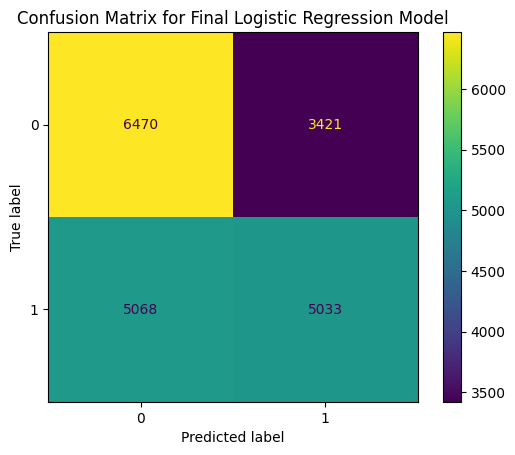

In [170]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Convert best logistic parameters from hyperopt-friendly types to sklearn-compatible
log_params = {
    'C': float(0.012950209865415197),  # already float
    'penalty': 'l2',                   # penalty index 0 -> 'l2'
    'solver': 'lbfgs'                  # solver index 1 -> 'lbfgs'
}

# Create and train the model
log_model = LogisticRegression(**log_params, max_iter=1000)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Fit the model
log_model.fit(X_train, y_train)

# Predict
y_pred = log_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {acc:.4f}")

# Confusion Matrix
matrix = confusion_matrix(y_test, y_pred)
cm = ConfusionMatrixDisplay(matrix)
cm.plot()
plt.title("Confusion Matrix for Final Logistic Regression Model")
plt.show()


In [171]:
## The accuracy is more for the LOGISTIC REGRESSION . We are using this model for furthur use.

#### Data set is collected from the consumer finance USA government.
#### Complaint column can be removed reason it has more unique values its not good for our model
#### Columns we are removed doesnt have any impact on the target variable and create noise for the model.
#### Null values ca be imputed with the mode or else with the LbelEncoder etc.